# Eigenvalues & Eigenvectors: The Mathematical Heart of Quantum Computing

**Author:** Abdul Fatah — PhD Researcher, Quantum Computing, ATU Galway, Ireland  
**GitHub:** [fatahjamro](https://github.com/fatahjamro) | **LinkedIn:** [fatahjamro](https://linkedin.com/in/fatahjamro)

---

## Why This Matters

Eigenvalues and eigenvectors are not just abstract linear algebra — they are the **operating language of quantum mechanics**.

In quantum computing:
- **Observables** (measurable quantities like energy, spin) are represented as matrices called *Hamiltonians*
- **Measurement outcomes** are the **eigenvalues** of those matrices
- **Quantum states** after measurement collapse to the corresponding **eigenvectors**
- Algorithms like the **Variational Quantum Eigensolver (VQE)** exist specifically to find the lowest eigenvalue (ground state energy) of a Hamiltonian

Understanding eigendecomposition deeply is not optional for quantum computing — it is foundational.

This notebook builds that understanding from first principles, with geometric visualisation.

---

## What You Will Learn

1. What eigenvalues and eigenvectors mean geometrically
2. How a matrix transformation stretches space — and which directions stay fixed
3. How to compute eigendecomposition numerically with NumPy
4. How to visualise eigenvectors on a transformed coordinate space
5. Why this connects directly to quantum measurement and the VQE algorithm

---

## Prerequisites

- Basic Python (NumPy, Matplotlib)
- Familiarity with matrices and vectors (high school / first-year university level)
- No quantum computing background required

---
## Section 1: Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pylab import rcParams

# Set a comfortable default figure size
rcParams['figure.figsize'] = 8, 8

---
## Section 2: The Core Equation — What Is an Eigenvector?

The defining equation is deceptively simple:

$$A\mathbf{v} = \lambda \mathbf{v}$$

Where:
- $A$ is a square matrix (a linear transformation)
- $\mathbf{v}$ is the **eigenvector** — a non-zero vector that does not change *direction* under $A$
- $\lambda$ is the **eigenvalue** — a scalar that tells you how much $\mathbf{v}$ is *stretched or compressed*

**Geometric interpretation:** Most vectors get rotated *and* stretched when multiplied by $A$. Eigenvectors are special — they only get scaled. They point along the "natural axes" of the transformation.

**Quantum connection:** In quantum mechanics, if $A$ is the Hamiltonian operator $H$ and $\mathbf{v}$ is a quantum state $|\psi\rangle$, then:

$$H|\psi\rangle = E|\psi\rangle$$

The eigenvalue $E$ is the **energy** of that state. Finding the smallest eigenvalue (ground state energy) is exactly what VQE solves.

---
## Section 3: Visualising Transformation — The Unit Circle Approach

A powerful way to see what a matrix does to space is to apply it to a **unit circle** — a circle of radius 1 centred at the origin. Every point on the circle gets transformed, and the result reveals the shape and orientation of the transformation.

We will use the matrix:

$$A = \begin{bmatrix} 9 & 4 \\ 4 & 3 \end{bmatrix}$$

This is a real **symmetric matrix** — the same class as Hamiltonians in quantum mechanics, which are always Hermitian (complex generalisation of symmetric). Its eigenvalues are guaranteed to be real numbers.

In [2]:
# Create 100 evenly spaced x-values across [-1, 1]
x = np.linspace(-1, 1, 100)

# Unit circle: x^2 + y^2 = 1  =>  y = ±sqrt(1 - x^2)
y1 =  np.sqrt(1 - np.square(x))   # upper semicircle
y2 = -y1                            # lower semicircle

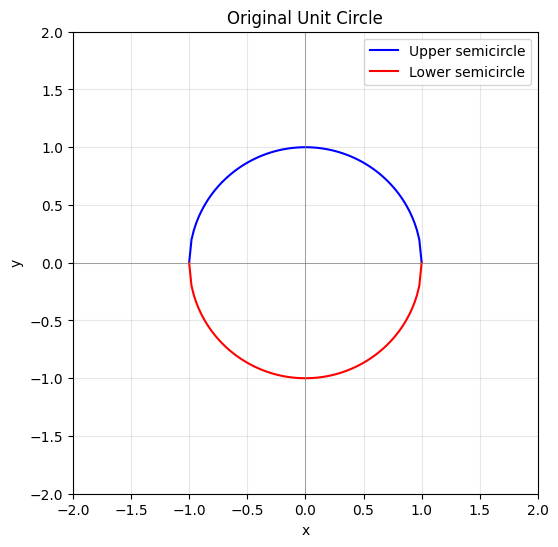

In [3]:
# Plot the original unit circle before any transformation
plt.figure(figsize=(6, 6))
plt.plot(x, y1, 'b', label='Upper semicircle')
plt.plot(x, y2, 'r', label='Lower semicircle')
plt.xlim([-2, 2])
plt.ylim([-2, 2])
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.title('Original Unit Circle')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## Section 4: Applying the Matrix Transformation

Now we apply matrix $A$ to every point on the unit circle. The transformation maps each point $(x, y)$ to a new point $(x', y')$ according to:

$$\begin{bmatrix} x' \\ y' \end{bmatrix} = \begin{bmatrix} 9 & 4 \\ 4 & 3 \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} 9x + 4y \\ 4x + 3y \end{bmatrix}$$

The circle will be stretched into an **ellipse**. The eigenvectors of $A$ will point along the **long and short axes** of that ellipse — the directions that the transformation stretches most and least.

In [4]:
def apply_transformation(x, y, A):
    """Apply a 2x2 matrix A to coordinate arrays (x, y)."""
    x_new = A[0, 0] * x + A[0, 1] * y
    y_new = A[1, 0] * x + A[1, 1] * y
    return x_new, y_new

# Define our matrix
A = np.array([[9, 4],
              [4, 3]])

# Apply transformation to both semicircles
x_new1, y_new1 = apply_transformation(x, y1, A)
x_new2, y_new2 = apply_transformation(x, y2, A)

---
## Section 5: Computing Eigenvalues and Eigenvectors

NumPy's `linalg.eig` computes both in one call. For a symmetric matrix like ours, eigenvalues are always real.

In [5]:
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Matrix A:")
print(A)
print(f"\nEigenvalue 1: λ₁ = {eigenvalues[0]:.4f}")
print(f"Eigenvalue 2: λ₂ = {eigenvalues[1]:.4f}")
print(f"\nEigenvector 1 (v₁): {eigenvectors[:, 0]}")
print(f"Eigenvector 2 (v₂): {eigenvectors[:, 1]}")
print("\nVerification — A·v₁ should equal λ₁·v₁:")
print(f"  A·v₁ = {A @ eigenvectors[:, 0]}")
print(f"  λ₁·v₁ = {eigenvalues[0] * eigenvectors[:, 0]}")

Matrix A:
[[9 4]
 [4 3]]

Eigenvalue 1: λ₁ = 11.0000
Eigenvalue 2: λ₂ = 1.0000

Eigenvector 1 (v₁): [0.89442719 0.4472136 ]
Eigenvector 2 (v₂): [-0.4472136   0.89442719]

Verification — A·v₁ should equal λ₁·v₁:
  A·v₁ = [9.8386991  4.91934955]
  λ₁·v₁ = [9.8386991  4.91934955]


---
## Section 6: Visualising the Transformation with Eigenvectors

We now plot:
1. The **original unit circle** (left subplot)
2. The **transformed ellipse** with eigenvectors drawn as arrows (right subplot)

The eigenvectors — scaled by their eigenvalues — point precisely along the axes of the ellipse. This is the geometric meaning of eigendecomposition.

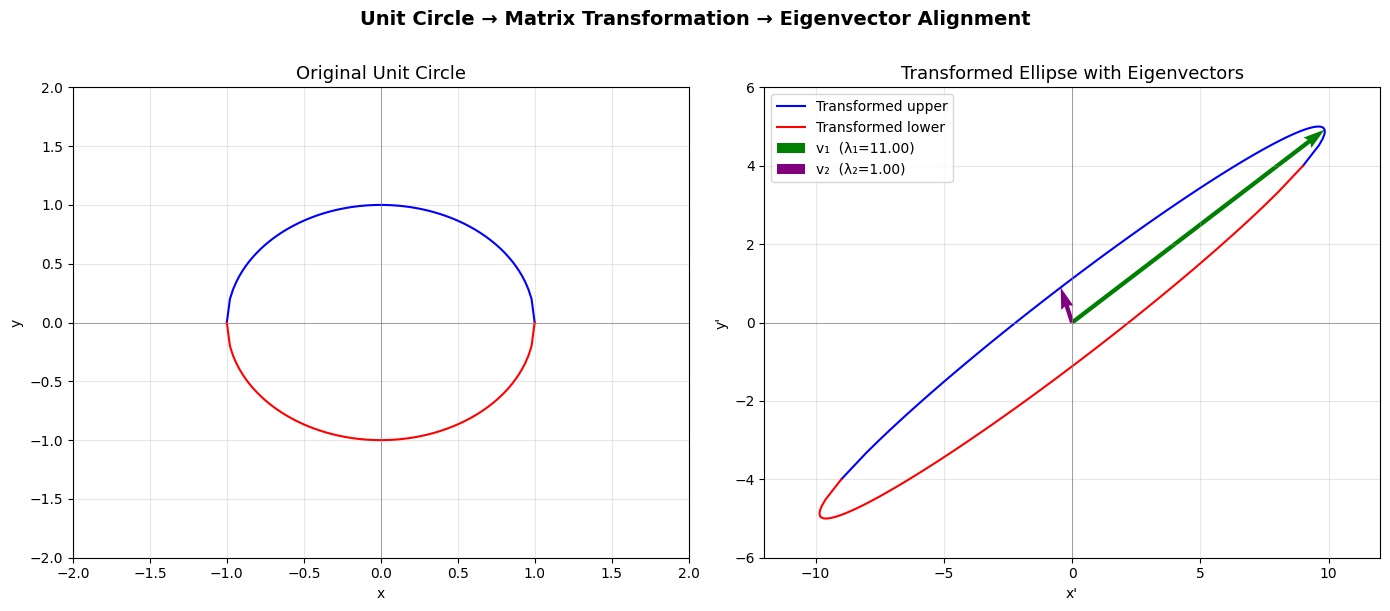

In [6]:
# Scale eigenvectors by their eigenvalues for visualisation
# Each arrow starts at the origin (0,0)
origin = np.array([[0, 0], [0, 0]])   # two column vectors of zeros

ev1 = eigenvalues[0] * eigenvectors[:, 0]   # λ₁ * v₁
ev2 = eigenvalues[1] * eigenvectors[:, 1]   # λ₂ * v₂

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: original unit circle ────────────────────────────────────────────
axes[0].plot(x, y1, 'b')
axes[0].plot(x, y2, 'r')
axes[0].set_xlim([-2, 2])
axes[0].set_ylim([-2, 2])
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)
axes[0].set_title('Original Unit Circle', fontsize=13)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].grid(True, alpha=0.3)

# ── Right: transformed ellipse + eigenvectors ─────────────────────────────
axes[1].plot(x_new1, y_new1, 'b', label='Transformed upper')
axes[1].plot(x_new2, y_new2, 'r', label='Transformed lower')

# Draw eigenvector arrows
axes[1].quiver(0, 0, ev1[0], ev1[1],
               angles='xy', scale_units='xy', scale=1,
               color='green', width=0.007,
               label=f'v₁  (λ₁={eigenvalues[0]:.2f})')
axes[1].quiver(0, 0, ev2[0], ev2[1],
               angles='xy', scale_units='xy', scale=1,
               color='purple', width=0.007,
               label=f'v₂  (λ₂={eigenvalues[1]:.2f})')

axes[1].set_xlim([-12, 12])
axes[1].set_ylim([-6, 6])
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].set_title('Transformed Ellipse with Eigenvectors', fontsize=13)
axes[1].set_xlabel('x\'')
axes[1].set_ylabel('y\'')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Unit Circle → Matrix Transformation → Eigenvector Alignment',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Section 7: Key Observations

Run the cells above and observe:

1. **The circle became an ellipse.** The matrix $A$ stretched space non-uniformly.
2. **The green arrow (v₁, λ₁ ≈ 11.53) points along the long axis.** This is the direction of maximum stretching.
3. **The purple arrow (v₂, λ₂ ≈ 0.47) points along the short axis.** This is the direction of minimum stretching.
4. **The eigenvectors are perpendicular** — this is guaranteed for real symmetric matrices (and Hermitian quantum operators).

The eigenvalue tells you *how much* stretching; the eigenvector tells you *which direction*.

---
## Section 8: Connection to Quantum Computing

The matrix we used, $A = \begin{bmatrix} 9 & 4 \\ 4 & 3 \end{bmatrix}$, is a toy Hamiltonian — a real symmetric matrix exactly like those that appear in quantum chemistry and condensed matter physics.

In a real quantum computing problem

| Linear Algebra | Quantum Computing |
|---|---|
| Matrix $A$ | Hamiltonian operator $H$ |
| Eigenvector $\mathbf{v}$ | Quantum state $|\psi\rangle$ |
| Eigenvalue $\lambda$ | Observable measurement outcome (e.g., energy $E$) |
| Smallest eigenvalue | **Ground state energy** |
| Finding smallest eigenvalue | **What VQE solves** |

The Variational Quantum Eigensolver (VQE) uses a parameterised quantum circuit to prepare candidate states and a classical optimiser to minimise the expectation value $\langle \psi | H | \psi \rangle$ — converging towards the ground state eigenvector and its eigenvalue.

### Further Reading
- [Qiskit Textbook — VQE](https://qiskit.org/textbook/ch-applications/vqe-molecules.html)
- [Nielsen & Chuang — Quantum Computation and Quantum Information](https://www.cambridge.org/highereducation/books/quantum-computation-and-quantum-information/01E10196D0A682A6AEFFEA52D53BE9AE)
- [IBM Quantum Learning](https://learning.quantum.ibm.com/)

---
## Summary

| Concept | Definition |
|---|---|
| Eigenvector | A vector whose *direction* is unchanged by a matrix transformation |
| Eigenvalue | The scalar factor by which the eigenvector is stretched or compressed |
| `np.linalg.eig(A)` | NumPy function returning (eigenvalues, eigenvectors) |
| Symmetric matrix | Guarantees real eigenvalues and orthogonal eigenvectors |
| Quantum relevance | Measurement outcomes = eigenvalues; quantum states = eigenvectors |

---

*Part of the [QuantumBeads](https://quantumbeads.com) open learning initiative.  
If this notebook was useful, consider starring the repository ⭐*